In [1]:
import numpy as np

Lets try to fit a difficult function. 

For now I want just to classify the positive and negative regions in the intervals (-10, 10)

Lets not use something from 3d but a simple 2d plot. Not so simple, but simple enough.

In [17]:
def binary_f(x:float, y:float) -> float:
    return np.where(
        np.logical_and(
            np.greater(y, 0.2*np.square(x) - 8),
            np.less(y, np.abs(x))
        ),
        1, 0
    )

In [11]:
x_space = np.linspace(-10, 10, 1000)
y_space = np.linspace(-10, 10, 1000)
pairs = [(x, y) for x, y in zip(x_space, y_space)]

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [19]:
xs, ys = np.meshgrid(x_space, y_space, sparse=True)
binary_zs = binary_f(xs, ys)

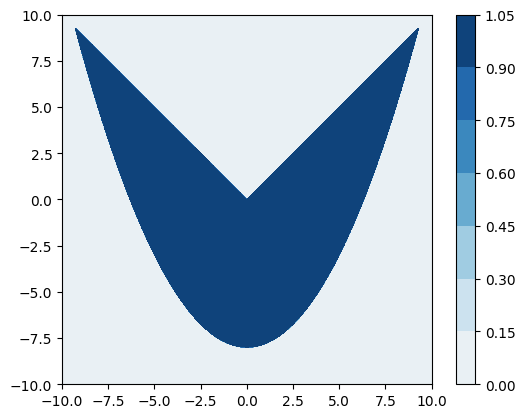

In [20]:
h = plt.contourf(
    x_space, y_space, binary_zs,
    cmap="RdBu", norm=TwoSlopeNorm(0))
plt.axis('scaled')
plt.colorbar()
plt.show()

In [14]:
# x_random = (10 - (-10)) * rng.random_sample((100)) + (-10)
# y_random = (10 - (-10)) * rng.random_sample((100)) + (-10)

In [21]:
rng = np.random.default_rng(12345)
x_random = (10 - (-10)) * rng.random((250,)) + (-10)
y_random = (10 - (-10)) * rng.random((250,)) + (-10)

In [22]:
z_random = binary_f(x_random, y_random)

In [23]:
rng_cv = np.random.default_rng(12)
x_cv = (10 - (-10)) * rng.random((250,)) + (-10)
y_cv = (10 - (-10)) * rng.random((250,)) + (-10)

In [24]:
z_cv = binary_f(x_cv, y_cv)

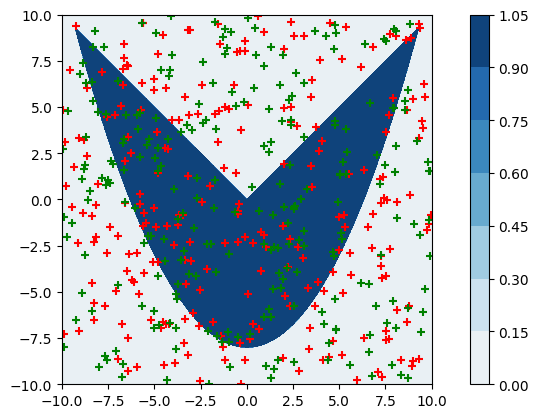

In [25]:
h = plt.contourf(
    x_space, y_space, binary_zs,
    cmap="RdBu", norm=TwoSlopeNorm(0))
plt.colorbar()
s = plt.scatter(
    x_random, y_random, color="r", marker="+"
)

s = plt.scatter(
    x_cv, y_cv, color="g", marker="+"
)
plt.axis('scaled')
plt.show()

/tmp/ipykernel_78486/2940418231.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


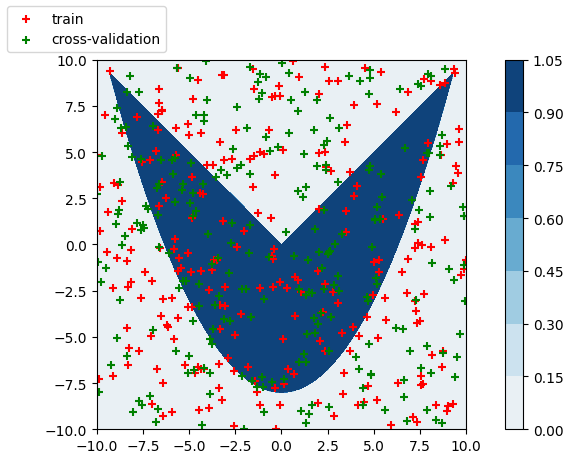

In [26]:
fig, ax = plt.subplots()

h = ax.contourf(
    x_space, y_space, binary_zs,
    cmap="RdBu", norm=TwoSlopeNorm(0))
fig.colorbar(
    h
)
s = ax.scatter(
    x_random, y_random, color="r", marker="+", label="train"
)

s = ax.scatter(
    x_cv, y_cv, color="g", marker="+", label="cross-validation"
)
fig.legend(loc="outside upper left")
ax.axis('scaled')
fig.show()

In [27]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy

2025-12-03 23:00:54.683657: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 23:00:55.191536: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 23:00:56.798505: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [28]:
rng = np.random.default_rng(12345)
x_random = (10 - (-10)) * rng.random((2_500,)) + (-10)
y_random = (10 - (-10)) * rng.random((2_500,)) + (-10)
z_random = binary_f(x_random, y_random)

In [29]:
training_X = np.stack((x_random, y_random), axis=-1)

In [30]:
training_Y = z_random

In [31]:
model = Sequential([
    Dense(units=2, activation='elu'),
    Dense(units=100, activation='elu'),
    Dense(units=1000, activation='elu'),
    Dense(units=100, activation='elu'),
    Dense(units=1, activation='linear')
])

In [32]:
model.compile(
    loss=BinaryCrossentropy(from_logits=True)
)

# Getting some issues
# https://stackoverflow.com/questions/59499764/tensorflow-not-tensorflow-gpu-failed-call-to-cuinit-unknown-error-303

In [33]:
model.fit(training_X, training_Y, epochs=1_000)

Epoch 1/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5248 
Epoch 2/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3482
Epoch 3/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3302
Epoch 4/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3030
Epoch 5/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2836
Epoch 6/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2578
Epoch 7/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2351
Epoch 8/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2267
Epoch 9/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2229
Epoch 10/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2150
Epoch 11/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2090
Epoch 12/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2103
Epoch 13/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2015
Epoch 14/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2051
Epoch 15/1000
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

In [34]:
model.save("../models/simple_small_model.keras")

In [35]:
x_space = np.linspace(-10, 10, 1000)
y_space = np.linspace(-10, 10, 1000)
xs, ys = np.meshgrid(x_space, y_space)

In [36]:
X_universe = np.stack(
    (
        np.reshape(xs, (xs.shape[0]*xs.shape[0],)), 
        np.reshape(ys, (ys.shape[0]*ys.shape[0]))
    ),
    axis=-1
)

In [37]:
all_space_results = tf.nn.sigmoid(model(X_universe)).numpy()
all_space_results = np.reshape(all_space_results, (all_space_results.shape[0],))
all_space_results_binary = np.where(all_space_results>0.5, 1, 0)

In [38]:
all_space_results_binary = np.reshape(all_space_results_binary, (xs.shape[0], xs.shape[0]))

In [39]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

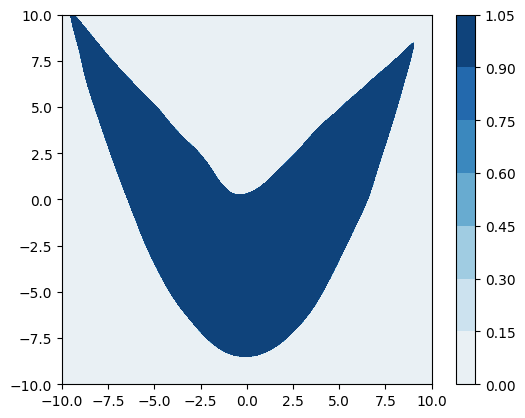

In [40]:
h = plt.contourf(
    x_space, y_space, all_space_results_binary,
    cmap="RdBu", norm=TwoSlopeNorm(0))
plt.axis('scaled')
plt.colorbar()
plt.show()